# Hochschule für Bildende Künste Braunschweig - Mapping

In [4]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [6]:
client = bigquery.Client(project='subugoe-collaborative')

In [7]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Hochschule für Bildende Künste Braunschweig' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/03aft2f80' -- 'Hochschule für Bildende Künste Braunschweig'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [8]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule für Bildende Künste Braunschweig,"Institut für Designforschung, Hochschule für B...",https://openalex.org/W4396670629
1,not assigned,Hochschule für Bildende Künste Braunschweig,"Institute of Geoecology, Technische Universitä...",https://openalex.org/W4283165652
2,not assigned,Hochschule für Bildende Künste Braunschweig,TU Braunschweig: Technische Universitat Brauns...,https://openalex.org/W4384070692
3,not assigned,Hochschule für Bildende Künste Braunschweig,"Helmholtz Centre for Infection Research, Epide...",https://openalex.org/W4206832248
4,not assigned,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig [B...,https://openalex.org/W4388900930


In [14]:
MAPPING_DICT = {
    'Institut für Designforschung (IDF)': ['designforschung'],
    #'Institut für Kunstwissenschaft (IKW)': [],
    #'Institut für Medienwissenschaft (IMW)': [],
    #'Institut Performative Praxis, Kunst und Bildung (IPKB)': []
}

In [15]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [16]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [17]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Institut für Designforschung (IDF),Hochschule für Bildende Künste Braunschweig,"Institut für Designforschung, Hochschule für B...",https://openalex.org/W4396670629
1,None,Hochschule für Bildende Künste Braunschweig,"Institute of Geoecology, Technische Universitä...",https://openalex.org/W4283165652
2,None,Hochschule für Bildende Künste Braunschweig,TU Braunschweig: Technische Universitat Brauns...,https://openalex.org/W4384070692
3,None,Hochschule für Bildende Künste Braunschweig,"Helmholtz Centre for Infection Research, Epide...",https://openalex.org/W4206832248
4,None,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig [B...,https://openalex.org/W4388900930
5,None,Hochschule für Bildende Künste Braunschweig,Braunschweig Integrated Center of Systems Biol...,https://openalex.org/W4366825021
6,None,Hochschule für Bildende Künste Braunschweig,"Professor, Centre for Light and Environmentall...",https://openalex.org/W4386229642
7,None,Hochschule für Bildende Künste Braunschweig,"Computational Biology of Infection Research, H...",https://openalex.org/W4416425542
8,None,Hochschule für Bildende Künste Braunschweig,"Computational Biology of Infection Research, H...",https://openalex.org/W4416425542
9,None,Hochschule für Bildende Künste Braunschweig,"From Medizinische Hochschule Hannover, Excelle...",https://openalex.org/W4381598176


In [18]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['Institute of Geoecology, Technische Universität Braunschweig, 38106, Braunschweig, Germany; Institute of Crop Science, University of Hohenheim, 70599, Stuttgart, Germany',
       'TU Braunschweig: Technische Universitat Braunschweig, Institute for Particle Technology, Volkmaroder Str. 5, 38106 Braunschweig, GERMANY',
       'Helmholtz Centre for Infection Research, Epidemiology Research Group Epidemiological and Statistical Methods, 38124 Braunschweig, Germany; Interdisciplinary Center for Health Sciences, Institute for Medical Epidemiology, Biometrics and Informatics, Medical School of the Martin Luther University Halle-Wittenberg, 06112 Halle (Saale), Germany',
       'Hochschule für Bildende Künste Braunschweig [Braunschweig University of Art] Germany',
       'Braunschweig Integrated Center of Systems Biology (BRICS), Technical University, Braunschweig, Germany; Microbial Genome Research, Leibniz Institute DSMZ - German Collection of Microorganisms and Cell Cultures, Brauns

In [19]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Institut für Designforschung (IDF),1
1,NaN,16


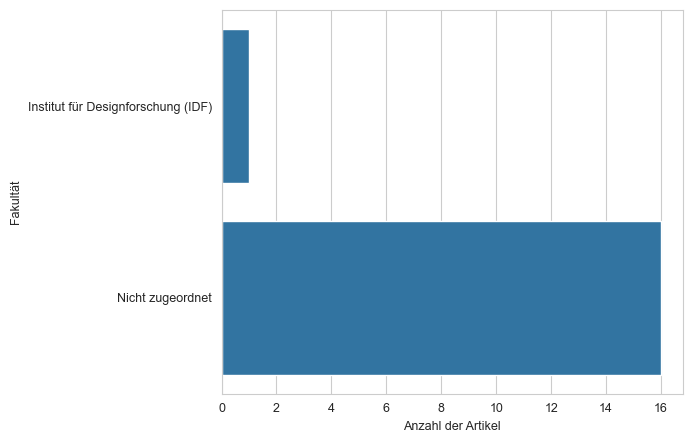

In [20]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [21]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.058823529411764705